In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Load dataset
df = pd.read_csv("student_performance_updated_1000.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

print("Columns:", df.columns)

# Remove nulls & duplicates
df = df.dropna()
df = df.drop_duplicates()

Columns: Index(['studentid', 'name', 'gender', 'attendancerate', 'studyhoursperweek',
       'previousgrade', 'extracurricularactivities', 'parentalsupport',
       'finalgrade', 'study hours', 'attendance (%)', 'online classes taken'],
      dtype='object')


In [3]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numeric columns:", numeric_cols)

target_col = numeric_cols[-1]
print("Using target column:", target_col)

df['final_score'] = df[target_col]

Numeric columns: ['studentid', 'attendancerate', 'studyhoursperweek', 'previousgrade', 'extracurricularactivities', 'finalgrade', 'study hours', 'attendance (%)']
Using target column: attendance (%)


In [4]:
def grade_category(score):
    if score >= 85:
        return "A"
    elif score >= 70:
        return "B"
    elif score >= 50:
        return "C"
    else:
        return "D"

df['grade_category'] = df['final_score'].apply(grade_category)

In [5]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype('category').cat.codes

In [6]:
df.to_csv("cleaned_data.csv", index=False)
print("✅ Cleaned dataset saved")

✅ Cleaned dataset saved


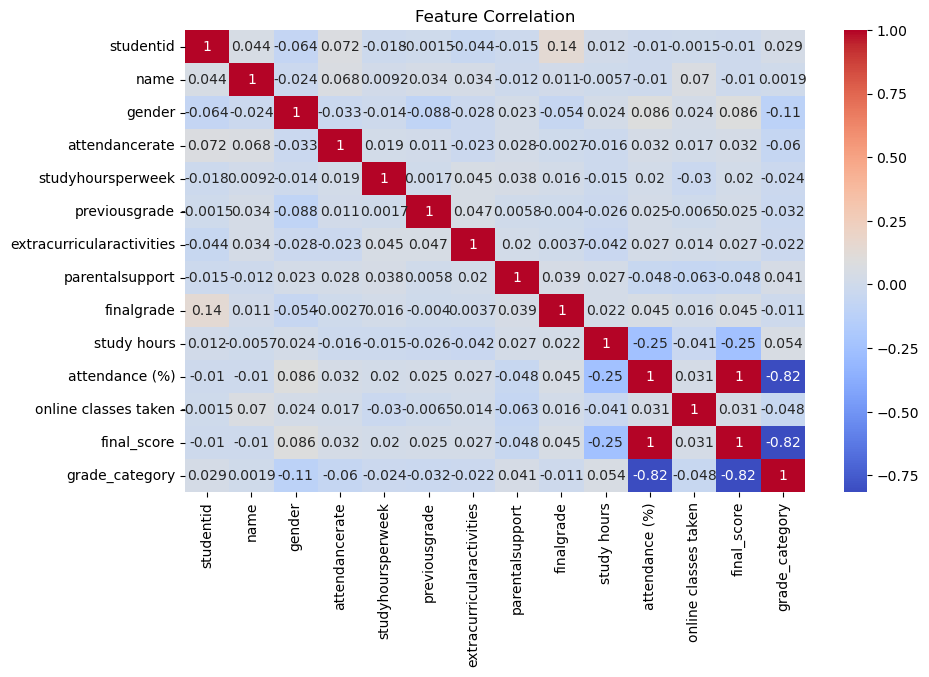

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

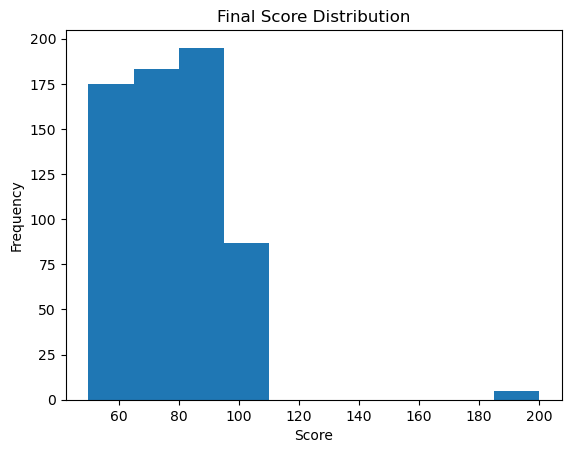

In [8]:
plt.hist(df['final_score'])
plt.title("Final Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [9]:
if 'study_hours' in df.columns:
    plt.scatter(df['study_hours'], df['final_score'])
    plt.xlabel("Study Hours")
    plt.ylabel("Final Score")
    plt.title("Study Hours vs Score")
    plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Encode target
le = LabelEncoder()
df['grade_encoded'] = le.fit_transform(df['grade_category'])

# Features & target
X = df.drop(['grade_category', 'grade_encoded'], axis=1)
y = df['grade_encoded']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Model Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       1.00      1.00      1.00        35
           2       1.00      1.00      1.00        47

    accuracy                           1.00       129
   macro avg       1.00      1.00      1.00       129
weighted avg       1.00      1.00      1.00       129


Confusion Matrix:
 [[47  0  0]
 [ 0 35  0]
 [ 0  0 47]]


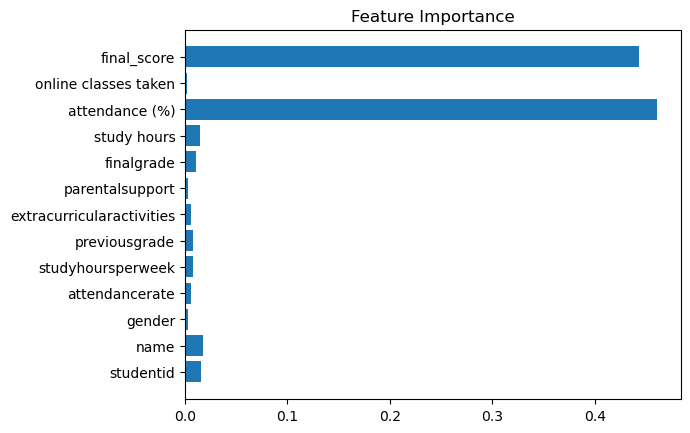

In [11]:
importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [15]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Scatter plot
fig1 = px.scatter(
    df,
    x=df.columns[0],
    y="final_score",
    color="grade_category"
)

# Histogram
fig2 = px.histogram(
    df,
    x="final_score",
    nbins=20
)

# Box plot
fig3 = px.box(
    df,
    x="grade_category",
    y="final_score"
)

# Combine into dashboard
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Scatter Plot", "Score Distribution", "Box Plot", "")
)

fig.add_trace(fig1.data[0], row=1, col=1)
fig.add_trace(fig2.data[0], row=1, col=2)
fig.add_trace(fig3.data[0], row=2, col=1)

fig.update_layout(
    height=700,
    title_text="📊 Student Academic Insights Dashboard"
)

fig.show()

# Save outputs
fig.write_image("dashboard.png")

In [13]:
!pip install kaleido

In [14]:
fig.write_image("dashboard.png")